# Long-Horizon Emissions Forecasting for 2030 Target Assessment: A Comparative Study of N-HiTS, XGBoost, and Bayesian Models in Fast-Moving Consumer Goods Supply Chains
**Authors**: Idris Alugo 

**Paper**: *Applied Energy* (submitted 2026)  
**Zenodo DOI**: [to be assigned]

This notebook orchestrates the full pipeline:
1. Data loading & feature engineering  
2. Per-facility model training (N-HiTS, XGBoost-Quantile, BNN)  
3. Out-of-fold meta-feature construction  
4. Stacking ensemble (meta-learner) training  
5. 2030 forecast generation  
6. Risk & compliance assessment  
7. SHAP explainability  
8. Publication figures

All heavy logic lives in `src/` — this notebook is the **single entry point** to reproduce all results.


## 0. Environment

In [1]:
import sys, importlib
print(f"Python {sys.version}")

required = [
    "numpy", "pandas", "torch", "xgboost",
    "neuralforecast", "shap", "sklearn",
    "matplotlib", "seaborn", "scipy",
]
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f"  ✓ {pkg}")
    except ImportError:
        missing.append(pkg)
        print(f"  ✗ {pkg}  ← MISSING")

if missing:
    raise ImportError(f"Install missing packages: pip install {' '.join(missing)}")
else:
    print("\nAll dependencies satisfied.")


Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
  ✓ numpy
  ✓ pandas
  ✓ torch
  ✓ xgboost


c:\Users\Idris\Downloads\Applied Energy\emissions-forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-27 00:28:50,050	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-27 00:28:50,335	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


  ✓ neuralforecast
  ✓ shap
  ✓ sklearn
  ✓ matplotlib
  ✓ seaborn
  ✓ scipy

All dependencies satisfied.


## 1. Imports & Logging

In [2]:
import logging
import warnings
import numpy as np
import pandas as pd

# src modules
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # adjust if running from notebooks/

from config import (
    DATA_PATH, TARGET_COL, TEST_MONTHS, RANDOM_SEED,
    BASELINE_YEAR, TARGET_REDUCTION_RATE, MIN_TRAIN_ROWS,
)
from src.preprocessing import (
    load_and_clean_data,
    create_global_features_with_hierarchy,
)
from src.models.nhits_model   import run_nhits, predict_nhits_2030, shap_nhits
from src.models.xgboost_model import run_xgboost_quantile, predict_xgboost_2030, shap_xgboost
from src.models.bnn_model     import run_bnn, mc_predict_bnn, shap_bnn
from src.models.meta_learner  import (
    build_meta_features, train_meta_learner,
    predict_ensemble, evaluate_meta_learner,
)
from src.evaluation import (
    prepare_facility_targets,
    compute_calibrated_probabilities,
    compute_stakeholder_metrics,
    compare_model_metrics,
    compute_regional_summary,
    aggregate_shap_records,
    compute_portfolio_probability,
)
from src.visualization import plot_all

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("pipeline")
np.random.seed(RANDOM_SEED)
logger.info("Imports complete.")

00:28:50  INFO      pipeline — Imports complete.


## 2. Data Loading & Feature Engineering

In [3]:
# Load and clean raw data
df_raw = load_and_clean_data(DATA_PATH)
logger.info("Raw data: %s", df_raw.shape)

# Define base numeric features (before hierarchy/lag enrichment)
BASE_NUMERIC_FEATURES = [
    "Month", "Year", "DayOfYear",
    "Production", "Energy_MWh", "Waste_Kg",
    "Renewable_percent", "PolicyWeight",
]
region_cols = [c for c in df_raw.columns if c.startswith("Region_")]
base_features = BASE_NUMERIC_FEATURES + region_cols

# Create enhanced feature set (lags, rolling stats, hierarchy embeddings)
df, global_scalers, features = create_global_features_with_hierarchy(df_raw, base_features)

logger.info("Enhanced data: %s | Features: %d", df.shape, len(features))
logger.info("Facilities: %s", df["Facility"].nunique())
df.head(3)

00:28:50  INFO      src.preprocessing — Loaded 2057 rows from C:\Users\Idris\Downloads\Applied Energy\emissions-forecast\data\esgdata.csv
00:28:50  INFO      src.preprocessing — Removed 1173 rows (outlier facilities). Remaining: 884
00:28:50  INFO      src.preprocessing — Date filter [2016–2023]: 478 rows remain
00:28:50  INFO      src.preprocessing — Region dummies added: ['Region_R1', 'Region_R3', 'Region_R7']
00:28:50  INFO      pipeline — Raw data: (478, 17)
00:28:51  INFO      src.preprocessing — NOTE: Target Emissions_tCO2 kept in ORIGINAL scale (y-scaler fitted but not applied).
00:28:51  INFO      src.preprocessing — Feature engineering complete. Base: 11 | Lags: 8 | Hierarchy: 4 | Interactions: 2 | Rolling/Trend: 3 | Total: 28
00:28:51  INFO      pipeline — Enhanced data: (478, 34) | Features: 28
00:28:51  INFO      pipeline — Facilities: 20


,Date,Region,Facility,Energy_MWh,Emission_Factor,Production,Emissions_tCO2,Waste_Kg,Renewable_percent,Transport_Emissions,...,ProductionLag12,FacilityMeanEmission,FacilityStdEmission,RegionalMeanEmission,FacilityDeviationFromRegion,ProductionRegionInteraction,EnergyPolicyWeightInteraction,RegionRollingEmissions6M,RegionRollingEmissions12M,RegionalYearTrend
0,2022-01-01,R1,F10,-0.361519,EF,0.000218,40.50,-0.270903,0.0,0,...,0.000218,38.200833,6.850016,97.722586,-59.521753,0.000415,-0.0,40.500000,40.500000,-18.581905
286,2022-01-01,R1,F31,0.600102,EF,-0.189780,88.70,0.453446,0.0,0,...,0.000218,90.668750,9.057092,97.722586,-7.053836,-0.362003,0.0,64.600000,64.600000,-18.581905
24,2022-01-01,R1,F11,-0.286191,EF,1.316756,28.89,-0.300127,0.0,0,...,0.000218,22.518750,5.511983,97.722586,-75.203836,2.511704,-0.0,52.696667,52.696667,-18.581905


## 2b. Facility Emissions Profile Clustering


00:28:52  INFO      src.models.clustering_model — Silhouette scores: {2: 0.6919144626099543, 3: 0.6414176492255979, 4: 0.44354796551860665, 5: 0.3946955493212292, 6: 0.3551332948312741, 7: 0.36210120251933725, 8: 0.32248536656918614}  |  selected K=3
00:28:52  INFO      src.models.clustering_model — Cluster [High Emitter]: n=2 (10%)  mean_emissions=703.0 tCO2  facilities=['F44', 'F43']
00:28:52  INFO      src.models.clustering_model — Cluster [Medium Emitter]: n=8 (40%)  mean_emissions=114.2 tCO2  facilities=['F27', 'F31', 'F22', 'F33', 'F18', 'F30', 'F28', 'F25']
00:28:52  INFO      src.models.clustering_model — Cluster [Low Emitter]: n=10 (50%)  mean_emissions=19.7 tCO2  facilities=['F4', 'F13', 'F17', 'F9', 'F19', 'F6', 'F11', 'F10', 'F7', 'F12']


-- Silhouette Scores --
  K=2  silhouette=0.6919
  K=3  silhouette=0.6414  <-- selected (elbow)
  K=4  silhouette=0.4435
  K=5  silhouette=0.3947
  K=6  silhouette=0.3551
  K=7  silhouette=0.3621
  K=8  silhouette=0.3225

-- Cluster Membership (K=3, manuscript-aligned) --
  High Emitter: 2 (10%)  mean=703.0 tCO2  -> F44, F43
  Medium Emitter: 8 (40%)  mean=114.2 tCO2  -> F27, F31, F22, F33, F18, F30, F28, F25
  Low Emitter: 10 (50%)  mean=19.7 tCO2  -> F4, F13, F17, F9, F19, F6, F11, F10, F7, F12


00:28:53  INFO      src.visualization — Saved: ../figures\figure7_facility_clusters.png


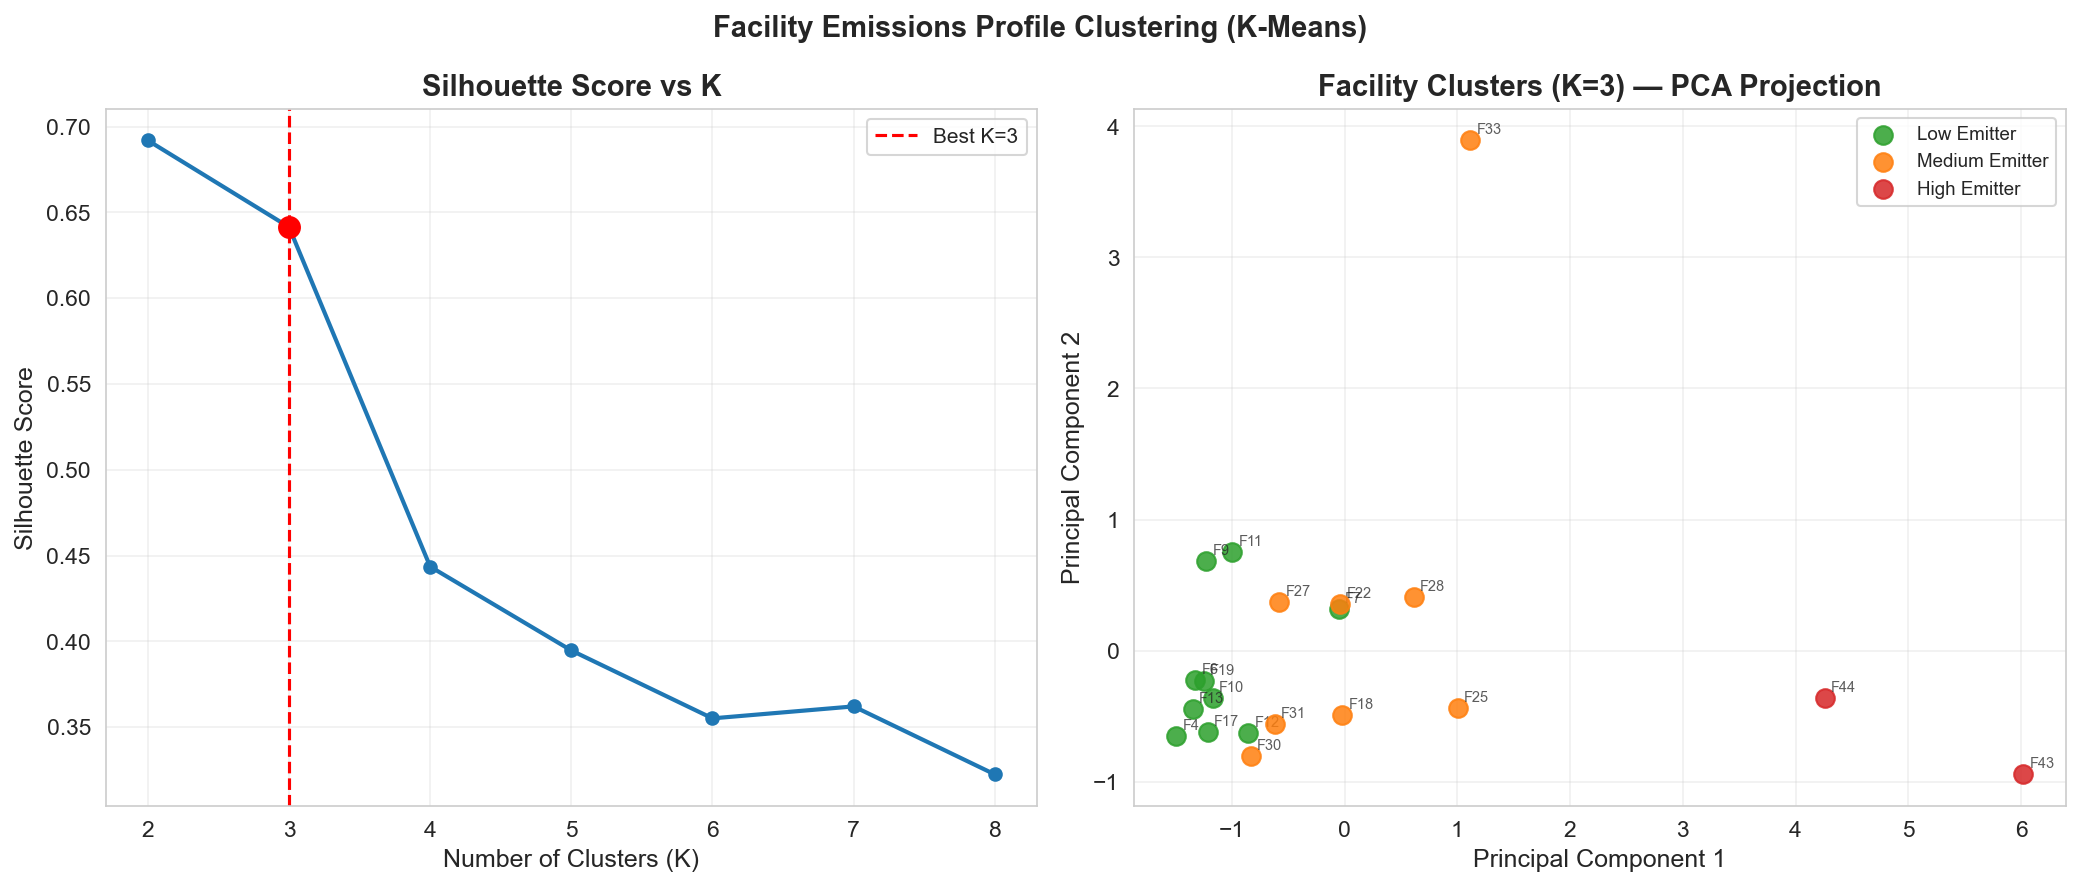


Saved: ../figures\figure7_facility_clusters.png


In [4]:
import os
from src.models.clustering_model import run_facility_clustering
from src.visualization import plot_facility_clusters

clust = run_facility_clustering(df_raw)

print("-- Silhouette Scores --")
for k, s in sorted(clust["sil_scores"].items()):
    marker = "  <-- selected (elbow)" if k == clust["best_k"] else ""
    print(f"  K={k}  silhouette={s:.4f}{marker}")

print("\n-- Cluster Membership (K=3, manuscript-aligned) --")
n_fac = len(clust["fac_df"])
for label, members in [
    ("High Emitter",   clust["high_facs"]),
    ("Medium Emitter", clust["medium_facs"]),
    ("Low Emitter",    clust["low_facs"]),
]:
    pct    = round(len(members) / n_fac * 100)
    mean_e = clust["fac_df"].loc[members, "MeanEmissions"].mean()
    print(f"  {label}: {len(members)} ({pct}%)  mean={mean_e:.1f} tCO2  -> {', '.join(members)}")

os.makedirs("../figures", exist_ok=True)
cluster_fig_path = plot_facility_clusters(
    clust["cluster_df"], clust["sil_scores"], clust["best_k"],
    output_dir="../figures", show=True,
)
print(f"\nSaved: {cluster_fig_path}")


## 3. Per-Facility Model Training

> Trains N-HiTS, XGBoost-Quantile, and BNN for each facility. Collects OOF predictions for meta-learning.

In [5]:
from sklearn.model_selection import TimeSeriesSplit

results          = []
meta_feature_records = []
shap_records     = []
SHAP_FEATURES    = ["Energy_MWh", "Production", "EmissionsLag1", "EmissionsLag3"]
shap_raw_rows    = {"nhits": [], "xgb": [], "bnn": []}
X_raw_rows       = {"nhits": [], "xgb": [], "bnn": []}
bnn_res_dict     = {}
xgb_res_dict     = {}
nhits_res_dict   = {}

tscv = TimeSeriesSplit(n_splits=3)

for fac in df["Facility"].unique():
    df_fac = df[df["Facility"] == fac].sort_values("Date").reset_index(drop=True)
    logger.info("=" * 60)
    logger.info("Facility: %s  (%d rows)", fac, len(df_fac))

    if len(df_fac) < MIN_TRAIN_ROWS or df_fac[TARGET_COL].nunique() < 2:
        logger.warning("Skipping %s — insufficient data or no target variance.", fac)
        continue

    nhits_oof = np.full(len(df_fac), np.nan)
    xgb_oof   = np.full(len(df_fac), np.nan)
    bnn_oof   = np.full(len(df_fac), np.nan)

    # ── Out-of-fold predictions (TimeSeriesSplit) ──────────────────────────
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(df_fac)):
        df_train = df_fac.iloc[train_idx]
        df_test  = df_fac.iloc[test_idx]
        n_test   = len(df_test)

        # N-HiTS OOF
        try:
            res = run_nhits(
                pd.concat([df_train, df_test], ignore_index=True),
                fac, features, TARGET_COL, test_months=n_test,
            )
            if res and res.get("model") is not None:
                for i, idx in enumerate(test_idx):
                    if i < len(res["y_pred"]):
                        nhits_oof[idx] = res["y_pred"][i]
        except Exception as e:
            logger.debug("N-HiTS OOF fold %d failed for %s: %s", fold_idx, fac, e)

        # XGBoost OOF
        try:
            res = run_xgboost_quantile(
                pd.concat([df_train, df_test], ignore_index=True),
                fac, features, TARGET_COL, test_months=n_test,
            )
            if res and res.get("models") and 0.5 in res["models"]:
                preds = res["models"][0.5].predict(df_test[features].values)
                for i, idx in enumerate(test_idx):
                    if i < len(preds):
                        xgb_oof[idx] = preds[i]
        except Exception as e:
            logger.debug("XGBoost OOF fold %d failed for %s: %s", fold_idx, fac, e)

        # BNN OOF
        try:
            res = run_bnn(
                pd.concat([df_train, df_test], ignore_index=True),
                fac, features, TARGET_COL, test_months=n_test, n_epochs=100,
            )
            if res and res.get("model") is not None:
                mc = mc_predict_bnn(res["model"], df_test[features].values)
                preds = mc.mean(axis=0)
                for i, idx in enumerate(test_idx):
                    if i < len(preds):
                        bnn_oof[idx] = preds[i]
        except Exception as e:
            logger.debug("BNN OOF fold %d failed for %s: %s", fold_idx, fac, e)

    # ── Final models trained on full facility data ─────────────────────────
    nhits_res = run_nhits(df_fac, fac, features, TARGET_COL, TEST_MONTHS)
    xgb_res   = run_xgboost_quantile(df_fac, fac, features, TARGET_COL, TEST_MONTHS)
    bnn_res   = run_bnn(df_fac, fac, features, TARGET_COL, TEST_MONTHS, n_epochs=300)

    nhits_res_dict[fac] = nhits_res
    xgb_res_dict[fac]   = xgb_res
    bnn_res_dict[fac]   = bnn_res

    results.append({
        "Facility":    fac,
        "NHITSMAPE":   nhits_res.get("mape", np.nan),
        "NHITSRMSE":   nhits_res.get("rmse", np.nan),
        "XGBoostMAPE": xgb_res.get("mape", np.nan),
        "XGBoostRMSE": xgb_res.get("rmse", np.nan),
        "BNNMAPE":     bnn_res.get("mape", np.nan),
        "BNNRMSE":     bnn_res.get("rmse", np.nan),
    })

    # ── Collect OOF meta-feature rows ─────────────────────────────────────
    for i in range(len(df_fac)):
        has_nhits = not np.isnan(nhits_oof[i])
        has_xgb   = not np.isnan(xgb_oof[i])
        has_bnn   = not np.isnan(bnn_oof[i])
        if has_nhits or has_xgb or has_bnn:
            meta_feature_records.append({
                "Facility": fac,
                "NHITS_OOF": nhits_oof[i] if has_nhits else 0.0,
                "XGB_OOF":   xgb_oof[i]   if has_xgb   else 0.0,
                "BNN_OOF":   bnn_oof[i]   if has_bnn   else 0.0,
                "y_true":    df_fac.iloc[i][TARGET_COL],
            })

    # ── SHAP analysis ──────────────────────────────────────────────────────
    X_val = df_fac[features].values[-TEST_MONTHS:]
    X_train_shap = df_fac[features].values[:-TEST_MONTHS]

    mean_abs_xgb = mean_abs_bnn = mean_abs_nhits = None
    _feat_idx = [features.index(f) for f in SHAP_FEATURES if f in features]

    if xgb_res and xgb_res.get("models") and 0.5 in xgb_res["models"]:
        try:
            sv = shap_xgboost(xgb_res["models"][0.5], X_val, features, fac, show_plot=False)
            if sv is not None:
                mean_abs_xgb = np.abs(sv).mean(axis=0)
                for _i in range(len(sv)):
                    _sr = {"Facility": fac}
                    _xr = {"Facility": fac}
                    for _j, _fn in zip(_feat_idx, SHAP_FEATURES):
                        _sr[_fn] = float(sv[_i, _j])
                        _xr[_fn] = float(X_val[_i, _j])
                    shap_raw_rows["xgb"].append(_sr)
                    X_raw_rows["xgb"].append(_xr)
        except Exception as e:
            logger.debug("XGB SHAP failed for %s: %s", fac, e)

    if bnn_res and bnn_res.get("model") is not None:
        try:
            sv = shap_bnn(bnn_res["model"], X_train_shap, X_val, features, fac, show_plot=False)
            if sv is not None:
                mean_abs_bnn = np.abs(sv).mean(axis=0)
                for _i in range(len(sv)):
                    _sr = {"Facility": fac}
                    _xr = {"Facility": fac}
                    for _j, _fn in zip(_feat_idx, SHAP_FEATURES):
                        _sr[_fn] = float(sv[_i, _j])
                        _xr[_fn] = float(X_val[_i, _j])
                    shap_raw_rows["bnn"].append(_sr)
                    X_raw_rows["bnn"].append(_xr)
        except Exception as e:
            logger.debug("BNN SHAP failed for %s: %s", fac, e)

    try:
        sv = shap_nhits(X_train_shap, X_val, features, fac, show_plot=False)
        if sv is not None:
            mean_abs_nhits = np.abs(sv).mean(axis=0)
            for _i in range(len(sv)):
                _sr = {"Facility": fac}
                _xr = {"Facility": fac}
                for _j, _fn in zip(_feat_idx, SHAP_FEATURES):
                    _sr[_fn] = float(sv[_i, _j])
                    _xr[_fn] = float(X_val[_i, _j])
                shap_raw_rows["nhits"].append(_sr)
                X_raw_rows["nhits"].append(_xr)
    except Exception as e:
        logger.debug("N-HiTS SHAP failed for %s: %s", fac, e)

    if any(x is not None for x in [mean_abs_xgb, mean_abs_bnn, mean_abs_nhits]):
        zeros = np.zeros(len(features))
        for i, feat in enumerate(features):
            shap_records.append({
                "Facility":        fac,
                "Feature":         feat,
                "MeanAbsSHAPNHITS": mean_abs_nhits[i] if mean_abs_nhits is not None else zeros[i],
                "MeanAbsSHAPXGB":   mean_abs_xgb[i] if mean_abs_xgb is not None else zeros[i],
                "MeanAbsSHAPBNN":   mean_abs_bnn[i] if mean_abs_bnn is not None else zeros[i],
            })

results_df = pd.DataFrame(results)
logger.info("Training complete. %d facilities.", len(results_df))
results_df[["Facility","NHITSMAPE","XGBoostMAPE","BNNMAPE"]]

00:28:53  INFO      pipeline — ============================================================
00:28:53  INFO      pipeline — Facility: F10  (24 rows)
00:28:53  WARNING   src.models.nhits_model — N-HiTS: insufficient data for F10 (12 rows).
00:28:53  WARNING   src.models.xgboost_model — XGBoost: insufficient data for F10 (12 rows).
00:28:53  WARNING   src.models.bnn_model — BNN: insufficient data for F10 (12 rows).
00:28:53  WARNING   src.models.nhits_model — N-HiTS: insufficient data for F10 (18 rows).
00:28:53  WARNING   src.models.xgboost_model — XGBoost: insufficient data for F10 (18 rows).
00:28:53  WARNING   src.models.bnn_model — BNN: insufficient data for F10 (18 rows).
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platfo

Epoch 149: 100%|██████████| 1/1 [00:00<00:00, 11.44it/s, v_num=2340, train_loss_step=0.538, train_loss_epoch=0.538]

`Trainer.fit` stopped: `max_steps=150` reached.


Epoch 149: 100%|██████████| 1/1 [00:00<00:00, 11.06it/s, v_num=2340, train_loss_step=0.538, train_loss_epoch=0.538]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 200.24it/s]

00:38:39  INFO      src.models.nhits_model — N-HiTS [F28] MAPE=43.85%  RMSE=49.3854  input_size=6


00:38:39  INFO      src.models.xgboost_model — XGBoost [F28] MAPE=19.53%  RMSE=25.0392
00:38:40  INFO      src.models.bnn_model — BNN [F28] MAPE=98.41%  RMSE=113.4935  val_loss=12983.960938
00:38:40  WARNING   src.models.xgboost_model — XGBoost SHAP failed for F28 (could not convert string to float: '[1.4579001E2]'). Trying native pred_contribs fallback.
00:38:40  INFO      src.models.xgboost_model — XGBoost fallback contributions computed for F28  shape=(12, 28)
  0%|          | 0/12 [00:00<?, ?it/s]00:38:40  INFO      shap — num_full_subsets = 0
00:38:40  INFO      shap — remaining_weight_vector = array([0.31428133, 0.16761671, 0.11972622, 0.09670195, 0.08380835,
       0.07618941, 0.07183573, 0.0698403 ])
00:38:40  INFO      shap — num_paired_subset_sizes = 8
00:38:40  INFO      shap — weight_left = 0.9999999999999999
00:38:40  INFO      shap — np.sum(w_aug) = 16.999999999999996
00:38:40  INFO      shap — np.sum(self.kernelWeights) = 0.9999999999999998
00:38:40  INFO      shap — phi

,Facility,NHITSMAPE,XGBoostMAPE,BNNMAPE
0,F10,25.143458,18.142969,96.112854
1,F31,10.807263,6.986576,96.974962
2,F11,41.728001,23.550584,92.267818
3,F13,83.202053,31.039591,23.817819
4,F4,46.121968,14.000000,15.989613
5,F30,19.495957,7.887079,97.612567
6,F9,140.333683,37.841493,45.001543
7,F43,32.916731,7.449395,99.064690
8,F27,20.622137,11.969080,96.611393
9,F12,73.481225,32.705306,85.824748


## 4. Meta-Learner Ensemble Training

In [6]:
import pandas as pd

if "meta_feature_records" not in globals():
    raise RuntimeError("Run Cell 8 (Per-Facility Model Training) before this cell.")

meta_df = pd.DataFrame(meta_feature_records)
logger.info("Meta-feature rows collected: %d", len(meta_df))

# Augment with uncertainty & agreement features
meta_df_enhanced = build_meta_features(meta_df, bnn_res_dict, xgb_res_dict)

# Train stacking ensemble
meta_models, meta_feature_cols, meta_weights = train_meta_learner(
    meta_df_enhanced, verbose=True
)
logger.info("Meta-learner weights: %s", meta_weights)

# OOF evaluation
oof_eval = evaluate_meta_learner(
    meta_models, meta_weights, meta_feature_cols,
    meta_df_enhanced,
    individual_oof_cols={"N-HiTS": "NHITS_OOF", "XGBoost": "XGB_OOF", "BNN": "BNN_OOF"},
)
logger.info("Ensemble OOF MAPE=%.2f%%  RMSE=%.4f", oof_eval["ensemble_mape"], oof_eval["ensemble_rmse"])
pd.DataFrame([oof_eval]).T


00:38:40  INFO      pipeline — Meta-feature rows collected: 119
00:38:40  INFO      src.models.meta_learner — Meta-features built: 119 rows, 13 columns
00:38:40  INFO      src.models.meta_learner — Meta-learner training: 119 samples × 11 features
00:38:44  INFO      src.models.meta_learner —   ridge      CV-MSE=1433.828235  Weight=0.312
00:38:44  INFO      src.models.meta_learner —   elastic    CV-MSE=1421.121343  Weight=0.315
00:38:44  INFO      src.models.meta_learner —   gbm        CV-MSE=2071.566895  Weight=0.216
00:38:44  INFO      src.models.meta_learner —   rf         CV-MSE=2853.411079  Weight=0.157
00:38:44  INFO      pipeline — Meta-learner weights: {'ridge': 0.3121503545347175, 'elastic': 0.3149414327213461, 'gbm': 0.21605384456696441, 'rf': 0.1568543681769719}
00:38:47  INFO      src.models.meta_learner — Ensemble OOF  MAPE=18.48%  RMSE=20.7465
00:38:47  INFO      src.models.meta_learner —   N-HiTS   MAPE=37.43%  Improvement vs ensemble: +18.95%
00:38:47  INFO      src.mode

,0
ensemble_mape,18.475348
ensemble_rmse,20.746468
individual_mapes,"{'N-HiTS': 37.42953310463859, 'XGBoost': 21.09..."
improvement,"{'N-HiTS': 18.954185513693226, 'XGBoost': 2.62..."


## 5. 2030 Forecast Generation

In [7]:
from src.preprocessing import prepare_2030_features

nhits_quantile_preds = {}
xgb_quantile_preds   = {}
bnn_mc_preds         = {}

for fac in results_df["Facility"].unique():
    df_fac = df[df["Facility"] == fac].copy()
    X_2030 = prepare_2030_features(df, fac, features, global_scalers, base_features)

    # N-HiTS
    nhits_res = nhits_res_dict.get(fac)
    if nhits_res and nhits_res.get("model") is not None:
        preds = predict_nhits_2030(nhits_res["model"], df_fac, fac, features)
        if preds:
            nhits_quantile_preds[fac] = preds

    # XGBoost
    xgb_res = xgb_res_dict.get(fac)
    if xgb_res and xgb_res.get("models"):
        preds = predict_xgboost_2030(xgb_res["models"], X_2030)
        if preds:
            xgb_quantile_preds[fac] = preds

    # BNN
    bnn_res = bnn_res_dict.get(fac)
    if bnn_res and bnn_res.get("model") is not None:
        samples = mc_predict_bnn(bnn_res["model"], X_2030)
        samples = np.clip(samples, 0, None)
        bnn_mc_preds[fac] = samples.flatten()

logger.info(
    "2030 forecasts: N-HiTS=%d  XGBoost=%d  BNN=%d",
    len(nhits_quantile_preds), len(xgb_quantile_preds), len(bnn_mc_preds),
)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 200.01it/s]


00:38:49  INFO      pipeline — 2030 forecasts: N-HiTS=20  XGBoost=20  BNN=20


## 6. Risk & Compliance Assessment

In [8]:
# Facility-level baselines and targets
facility_baseline = prepare_facility_targets(
    df_raw,
    baseline_year=BASELINE_YEAR,
    target_reduction=TARGET_REDUCTION_RATE,
)

# Per-facility compliance probabilities
risk_df = compute_calibrated_probabilities(
    facility_baseline,
    nhits_quantile_preds,
    xgb_quantile_preds,
    bnn_mc_preds,
    results_df,
    n_bootstrap=1000,
)

# Regional roll-up
regional_summary = compute_regional_summary(risk_df, facility_baseline)

# Model comparison
comparison_df = compare_model_metrics(results_df)

print("\n── Risk Distribution ──────────────────────────")
print(risk_df["RiskLevelEnsemble"].value_counts().to_string())
print("\n── Model Comparison ───────────────────────────")
print(comparison_df.to_string())

# Build forecasts_df from in-memory quantile dicts for portfolio bootstrap
forecast_rows_port = []
for fac in sorted(set(nhits_quantile_preds) | set(xgb_quantile_preds) | set(bnn_mc_preds)):
    nhits_p = nhits_quantile_preds.get(fac, {})
    xgb_p   = xgb_quantile_preds.get(fac, {})
    bnn_p   = bnn_mc_preds.get(fac)
    bnn_q10 = float(np.percentile(bnn_p, 10)) if bnn_p is not None else float("nan")
    bnn_q50 = float(np.percentile(bnn_p, 50)) if bnn_p is not None else float("nan")
    bnn_q90 = float(np.percentile(bnn_p, 90)) if bnn_p is not None else float("nan")
    forecast_rows_port.append({
        "Facility": fac,
        "NHITS_Q10": nhits_p.get(0.1, float("nan")), "NHITS_Q50": nhits_p.get(0.5, float("nan")), "NHITS_Q90": nhits_p.get(0.9, float("nan")),
        "XGB_Q10":   xgb_p.get(0.1, float("nan")),  "XGB_Q50":  xgb_p.get(0.5, float("nan")),  "XGB_Q90":  xgb_p.get(0.9, float("nan")),
        "BNN_Q10":   bnn_q10, "BNN_Q50": bnn_q50, "BNN_Q90": bnn_q90,
    })
forecasts_df_port = pd.DataFrame(forecast_rows_port)

portfolio_metrics = compute_portfolio_probability(
    risk_df, forecasts_df=forecasts_df_port, results_df=results_df,
    n_bootstrap=10_000_000,
)

print(f"\n── Portfolio Compliance ──────────────────────────────")
print(f"  P_portfolio (all 20 meet target)  = {portfolio_metrics['P_portfolio_pct']}")
print(f"  E[compliant facilities]           = {portfolio_metrics['E_compliant']:.2f} ± {portfolio_metrics['E_compliant_std']:.2f}")
print(f"  (out of {portfolio_metrics['N_facilities']} facilities, N={portfolio_metrics['N_bootstrap']:,} samples)")

# Uncertainty variance decomposition (Eq. 8)
_MAPE_GATE = 80.0
_decomp_rows = []
for _, _r in risk_df.iterrows():
    _fac = _r["Facility"]
    _a   = results_df[results_df["Facility"] == _fac]
    if _a.empty: continue
    _mapes = {"nhits": _a["NHITSMAPE"].values[0], "xgb": _a["XGBoostMAPE"].values[0], "bnn": _a["BNNMAPE"].values[0]}
    _means = {"nhits": _r["PredictionNHITS"], "xgb": _r["PredictionXGBoost"], "bnn": _r["PredictionBNN"]}
    _stds  = {"nhits": abs(_r["UncertaintyNHITS"]), "xgb": abs(_r["UncertaintyXGBoost"]), "bnn": abs(_r["UncertaintyBNN"])}
    _mods  = [k for k in ["nhits","xgb","bnn"] if not np.isnan(_mapes[k]) and _mapes[k] <= _MAPE_GATE and not np.isnan(_means[k]) and not np.isnan(_stds[k])]
    if not _mods: _mods = [k for k in ["nhits","xgb","bnn"] if not np.isnan(_means[k]) and not np.isnan(_stds[k])]
    if not _mods: continue
    _rw = np.array([1.0/(_mapes[k]+1.0) for k in _mods]); _w = _rw/_rw.sum()
    _mu = np.array([_means[k] for k in _mods]); _sig = np.array([_stds[k] for k in _mods])
    _mu_bar = float(np.dot(_w, _mu))
    _within = float(np.dot(_w, _sig**2)); _between = float(np.dot(_w, (_mu - _mu_bar)**2)); _total = _within + _between
    _decomp_rows.append({"Facility": _fac, "within_model_var": round(_within,4), "between_model_var": round(_between,4),
                          "total_var": round(_total,4), "within_pct": round(_within/_total*100,2) if _total>0 else float("nan"),
                          "between_pct": round(_between/_total*100,2) if _total>0 else float("nan")})
decomp_df = pd.DataFrame(_decomp_rows).sort_values("Facility")
logger.info("Variance decomposition: %d facilities", len(decomp_df))

00:38:49  INFO      src.evaluation — Targets prepared: 20 facilities | baseline_year=2022 | reduction=10%
00:38:49  INFO      src.evaluation — Compliance probabilities computed for 20 facilities. Risk distribution:
RiskLevelEnsemble
Low Risk       10
Medium Risk     8
High Risk       2
00:38:49  INFO      src.evaluation — Regional summary computed for 3 regions.
00:38:49  INFO      src.evaluation — Model comparison computed for 3 models.



── Risk Distribution ──────────────────────────
RiskLevelEnsemble
Low Risk       10
Medium Risk     8
High Risk       2

── Model Comparison ───────────────────────────
         Mean MAPE (%)  Std MAPE (%)  Mean RMSE  Std RMSE  N Facilities
Model                                                                  
N-HiTS           53.40         47.21    47.5090   64.1418            20
XGBoost          23.02         15.56    20.1907   28.1123            20
BNN              75.20         33.32   115.5433  190.8594            20


## 7. SHAP Feature Importance

In [9]:
shap_summary = aggregate_shap_records(shap_records, features)

print("── Top 15 Features by Average SHAP Contribution ──")
print(
    shap_summary.head(15)[
        ["Feature", "NHITSContribution", "XGBContribution",
         "BNNContribution", "AvgContribution", "Cumulative"]
    ].to_string(index=False)
)


00:38:49  INFO      src.evaluation — SHAP aggregated: top-5=71.5%  top-10=96.3%  features for 80% coverage=7


── Top 15 Features by Average SHAP Contribution ──
                    Feature  NHITSContribution  XGBContribution  BNNContribution  AvgContribution  Cumulative
              EmissionsLag3          34.034949         4.559046        53.089365        30.561120   30.561120
             EmissionsLag12          26.258919         0.000000        13.456641        13.238520   43.799640
                 Production           0.017223        28.328701         0.208954         9.518293   53.317933
   RegionRollingEmissions6M          10.963571         6.726795         9.612878         9.101081   62.419014
                 Energy_MWh           0.014076        27.122828         0.163721         9.100208   71.519223
              EmissionsLag1           7.108484         3.865743         9.900631         6.958286   78.477509
              EmissionsLag6          13.991466         0.651716         5.536319         6.726501   85.204009
  RegionRollingEmissions12M           6.914037         2.849092      

## 8. Publication Figures

In [ ]:
# Build shap_raw / X_raw DataFrames from the training loop accumulators
shap_raw = {m: pd.DataFrame(shap_raw_rows[m]) for m in ["nhits", "xgb", "bnn"]}
X_raw    = {m: pd.DataFrame(X_raw_rows[m])    for m in ["nhits", "xgb", "bnn"]}

saved_paths = plot_all(
    results_df    = results_df,
    risk_df       = risk_df,
    comparison_df = comparison_df,
    shap_summary  = shap_summary,
    output_dir    = "../figures",
    show          = True,          # set False for headless runs
    shap_raw      = shap_raw,
    X_raw         = X_raw,
    decomp_df     = decomp_df,
)
for p in saved_paths:
    print("Saved:", p)


## 9. Export Results

In [11]:
os.makedirs("../results", exist_ok=True)

results_df.to_csv("../results/model_accuracy.csv",      index=False)
risk_df.to_csv("../results/risk_assessment.csv",         index=False)
regional_summary.to_csv("../results/regional_summary.csv", index=False)
comparison_df.to_csv("../results/model_comparison.csv")

if len(shap_summary) > 0:
    shap_summary.to_csv("../results/shap_summary.csv", index=False)

# 2030 per-facility forecast quantiles
forecast_rows = []
for fac in sorted(set(nhits_quantile_preds) | set(xgb_quantile_preds) | set(bnn_mc_preds)):
    nhits_p = nhits_quantile_preds.get(fac, {})
    xgb_p   = xgb_quantile_preds.get(fac, {})
    bnn_p   = bnn_mc_preds.get(fac)
    forecast_rows.append({
        "Facility":  fac,
        "NHITS_Q10": nhits_p.get(0.1, float("nan")),
        "NHITS_Q50": nhits_p.get(0.5, float("nan")),
        "NHITS_Q90": nhits_p.get(0.9, float("nan")),
        "XGB_Q10":   xgb_p.get(0.1,  float("nan")),
        "XGB_Q50":   xgb_p.get(0.5,  float("nan")),
        "XGB_Q90":   xgb_p.get(0.9,  float("nan")),
        "BNN_Q10":   float(np.percentile(bnn_p, 10)) if bnn_p is not None else float("nan"),
        "BNN_Q50":   float(np.percentile(bnn_p, 50)) if bnn_p is not None else float("nan"),
        "BNN_Q90":   float(np.percentile(bnn_p, 90)) if bnn_p is not None else float("nan"),
    })
pd.DataFrame(forecast_rows).to_csv("../results/forecasts_2030.csv", index=False)


# Portfolio summary
pd.DataFrame([{
    'P_portfolio':     portfolio_metrics['P_portfolio'],
    'P_portfolio_pct': portfolio_metrics['P_portfolio_pct'],
    'E_compliant':     portfolio_metrics['E_compliant'],
    'E_compliant_std': portfolio_metrics['E_compliant_std'],
    'N_facilities':    portfolio_metrics['N_facilities'],
    'N_bootstrap':     portfolio_metrics['N_bootstrap'],
}]).to_csv('../results/portfolio_summary.csv', index=False)
portfolio_metrics['per_facility'].to_csv('../results/portfolio_per_facility.csv', index=False)

# Raw SHAP matrices for dependence plots
os.makedirs('../results/shap_raw', exist_ok=True)
for _m in ['nhits', 'xgb', 'bnn']:
    shap_raw[_m].to_csv(f'../results/shap_raw/shap_{_m}.csv', index=False)
    X_raw[_m].to_csv(f'../results/shap_raw/X_{_m}.csv', index=False)
logger.info('Raw SHAP matrices saved to ../results/shap_raw/')
decomp_df.to_csv('../results/uncertainty_decomposition.csv', index=False)
logger.info("All results exported to ../results/")
print("Done. Results written to ../results/")

00:38:53  INFO      pipeline — All results exported to ../results/


Done. Results written to ../results/
